# Lab 1 – Load and Explore the Data

In [1]:
# Task 1: Import the pandas library for data manipulation.
import pandas as pd

In [2]:
# Task 2: Load the 'train.csv' file into a DataFrame called df and preview the first rows.
df = pd.read_csv("train.csv")
df.head()

/tmp/ipykernel_74815/4292402596.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
# Task 3: Inspect the structure of the DataFrame using df.info().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [4]:
# Task 4: Print the unique values in 'StateHoliday' and their counts.
df['StateHoliday'].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [5]:
# Task 5: Binarize the 'StateHoliday' column so that any of 'a', 'b', or 'c' becomes 1 and 0 stays 0.
# Then, print the updated value counts.
df['StateHoliday'] = df['StateHoliday'].isin(['a', 'b','c']).astype(int)
df['StateHoliday'].value_counts()

StateHoliday
0    986159
1     31050
Name: count, dtype: int64

# Lab 2 – Subsetting Stores and Basic Aggregations

In [6]:
# Task 1: Count how many unique stores exist in the dataset.
print(f"There are {len(df.Store.unique())} stores")

There are 1115 stores


In [7]:
# Task 2: Subset the data to 10 random stores (seed = 1502) and store the result in df_10.
df_10 = df[df.Store.isin(df.Store.sample(10, random_state = 1502))].copy()
df_10

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
23,24,5,2015-07-31,14190,1082,1,1,0,1
46,47,5,2015-07-31,9379,1021,1,1,0,1
155,156,5,2015-07-31,8828,821,1,1,0,1
263,264,5,2015-07-31,8303,992,1,1,0,1
266,267,5,2015-07-31,11326,1217,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016447,353,2,2013-01-01,3139,820,1,0,1,1
1016857,763,2,2013-01-01,0,0,0,0,1,1
1016888,794,2,2013-01-01,0,0,0,0,1,1
1016956,862,2,2013-01-01,0,0,0,0,1,1


In [8]:
# Task 3: Compute the mean sales for each of the 10 stores and sort them in descending order.
df_10.groupby('Store')['Sales'].mean().sort_values(ascending = False)

Store
24     7763.773885
267    7731.106157
862    7128.519108
47     5946.666667
264    5851.901274
156    5779.171975
353    5579.376858
763    5097.873673
864    3520.780255
794    2553.475584
Name: Sales, dtype: float64

In [9]:
# Task 4: For each store, find the index (row) of the day with the all-time highest sales.
df_10.groupby('Store')['Sales'].idxmax().sort_values(ascending = False)

Store
864    947828
862    627821
156    627115
763    619917
264    455513
24     408443
794    245456
267    245014
353    101817
47      34611
Name: Sales, dtype: int64

# Lab 3 – Working with Datetime Index and Weekday Patterns

In [10]:
# Task 1: Set the 'Date' column as the index of df_10 and preview the first rows.
df_10.set_index('Date', inplace = True)
df_10.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,24,5,14190,1082,1,1,0,1
2015-07-31,47,5,9379,1021,1,1,0,1
2015-07-31,156,5,8828,821,1,1,0,1
2015-07-31,264,5,8303,992,1,1,0,1
2015-07-31,267,5,11326,1217,1,1,0,1


In [11]:
# Task 2: Convert the index of df_10 to a proper datetime type.
df_10.index = pd.to_datetime(df_10.index)
df_10.index

DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[ns]', name='Date', length=9420, freq=None)

In [12]:
# Task 3: Compute the average sales per weekday and per store.
df_10.groupby([df_10.index.dayofweek, 'Store'])['Sales'].mean()

Date  Store
0     24       10860.119403
      47        7877.686567
      156       8707.940299
      264       8320.291045
      267       8969.253731
                   ...     
6     353       7255.343284
      763          0.000000
      794          0.000000
      862          0.000000
      864          0.000000
Name: Sales, Length: 70, dtype: float64

<Axes: xlabel='Date'>

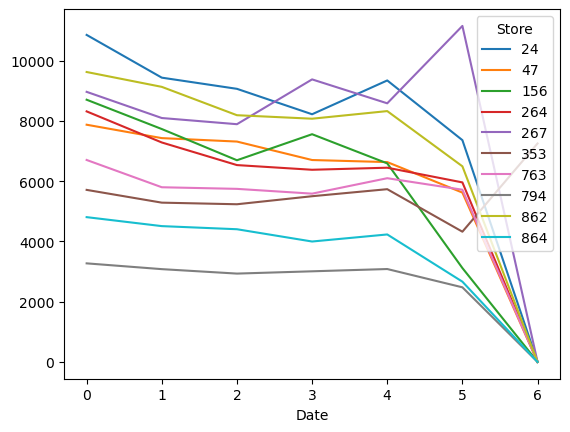

In [13]:
# Task 4: Visualize the average sales per weekday and per store as a line plot.
df_10.groupby([df_10.index.dayofweek, 'Store'])['Sales'].mean().unstack().plot()

# Lab 4 – Standardizing Sales and Comparing Weekday Patterns

In [14]:
# Task 1: Define a function that standardizes a numeric Series using z-scores.
def standardize(series):
  return (series - series.mean()) / series.std()

In [15]:
# Task 2: Standardize the 'Sales' column within each store and store the result in a new column 'Sales_std'.
df_10.loc[:, 'Sales_standardized'] = df_10.groupby('Store')['Sales'].transform(standardize)
df_10.head(2)

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
Date,,,,,,,,,
2015-07-31,24,5,14190,1082,1,1,0,1,1.504863
2015-07-31,47,5,9379,1021,1,1,0,1,1.103818


In [16]:
# Task 3: Compute the mean of standardized sales per weekday and per store.
df_10.groupby(['DayOfWeek', 'Store'])['Sales_standardized'].mean()

DayOfWeek  Store
1          24       0.725087
           47       0.621004
           156      0.799508
           264      0.702281
           267      0.293913
                      ...   
7          353      1.070822
           763     -1.945422
           794     -1.999880
           862     -1.901085
           864     -1.848743
Name: Sales_standardized, Length: 70, dtype: float64

In [31]:
# Task 4: Visualize the standardized mean sales per weekday and store as a line plot.
df_10.groupby(['DayOfWeek', 'Store'])['Sales_standardized'].mean().unstack()

Store,24,47,156,264,267,353,763,794,862,864
DayOfWeek,,,,,,,,,,
1,0.725087,0.621004,0.799508,0.702281,0.293913,0.085719,0.613992,0.563718,0.666669,0.675971
2,0.392676,0.477943,0.533739,0.408590,0.087619,-0.185123,0.268309,0.413313,0.535105,0.519535
3,0.305823,0.441101,0.250700,0.194974,0.038884,-0.219246,0.247897,0.297673,0.283970,0.465132
4,0.108094,0.243933,0.486816,0.150702,0.392171,-0.048780,0.187215,0.357132,0.253082,0.251037
5,0.370992,0.221909,0.222361,0.170175,0.203569,0.100577,0.382966,0.416359,0.320485,0.374162
6,-0.093378,-0.103813,-0.726646,0.031301,0.813673,-0.801337,0.236937,-0.059393,-0.168619,-0.449107
7,-1.818083,-1.912412,-1.577624,-1.664922,-1.835219,1.070822,-1.945422,-1.999880,-1.901085,-1.848743


# Lab 5 – Analyzing Sales on a Specific Weekday

In [34]:
df_d7.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
Date,,,,,,,,,
2015-07-26,24,7,0,0,0,0,0,0,-1.818083
2015-07-26,47,7,0,0,0,0,0,0,-1.912412
2015-07-26,156,7,0,0,0,0,0,0,-1.577624
2015-07-26,264,7,0,0,0,0,0,0,-1.664922
2015-07-26,267,7,0,0,0,0,0,0,-1.835219


<Axes: xlabel='Date'>

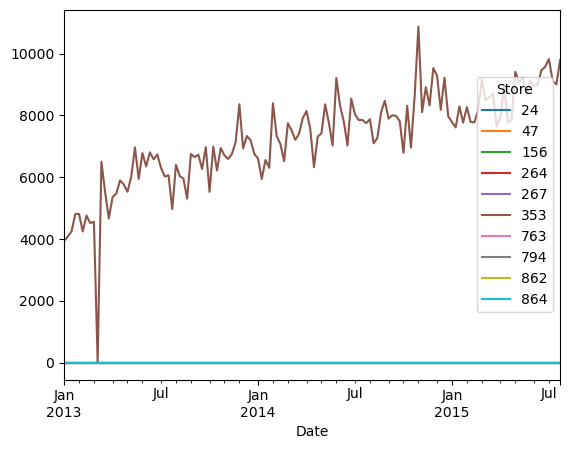

In [45]:
df_10.loc[df_10['DayOfWeek'] == 7, ['Store', 'Sales']].reset_index().pivot(index='Date', columns='Store', values='Sales').plot()

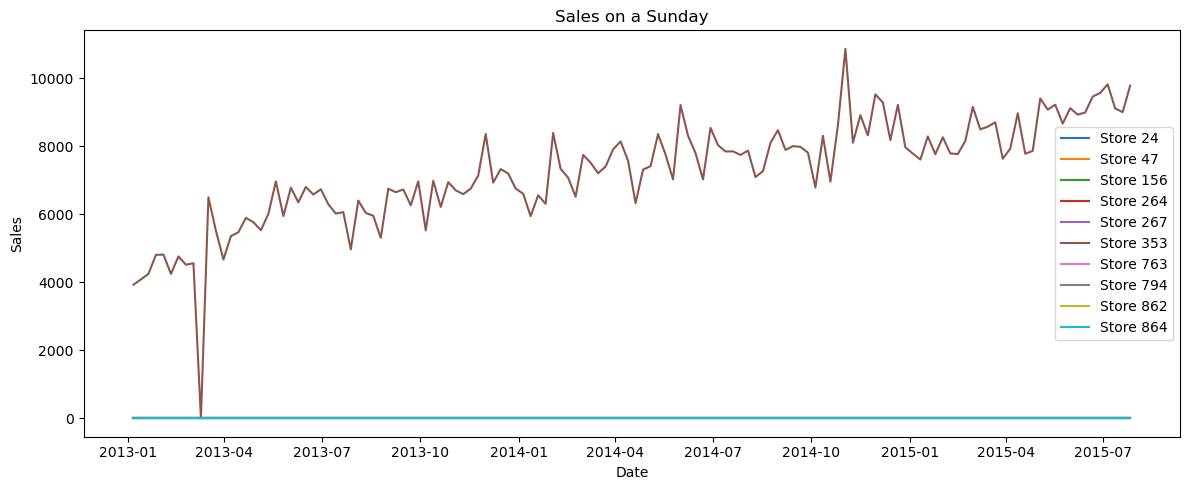

In [33]:
# Task 1: Filter the data to DayOfWeek = 7 and visualize sales over time for each store.
import matplotlib.pyplot as plt
df_d7 = df_10.loc[df_10['DayOfWeek'] == 7, :].copy()
plt.figure(figsize = (12, 5))
for store, data in df_d7.groupby('Store'):
    plt.plot(data.index, data.Sales, label=f'Store {store}')
plt.title('Sales on a Sunday')
plt.xlabel('Date')
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()



# Lab 6 – Removing Outliers and Re-Assessing Intra-Week Seasonality

In [19]:
# Task 1: Remove observations for DayOfWeek = 7 and for Store 353, and create a cleaned DataFrame df_clean.


In [20]:
# Task 2: Re-standardize the 'Sales' column within each store in df_clean.


In [21]:
# Task 3: Compute the mean of standardized sales per weekday and per store in df_clean.


In [22]:
# Task 4: Visualize the intra-week seasonality using the standardized sales.


# Lab 7 – Analyzing the Impact of Promotions

In [23]:
# Task 1: Compare average sales on promotion days versus non-promotion days.


In [24]:
# Task 2: Compute the mean sales per store split by promotion status and store the result in promo_uplift.


In [25]:
# Task 3: For each store, compute the relative uplift of sales during promotion days compared to non-promotion days.


In [26]:
# Task 4: Identify the top 5 stores with the highest relative promotion uplift.


In [27]:
# Task 5: Identify the 5 stores with the lowest (or most negative) relative promotion uplift.
